# Tổng quan TextRank cho toàn bộ tài liệu DUC train

Notebook chạy độc lập toàn bộ file trong `data/DUC_TEXT/train`. Mỗi topic được xử lý riêng bằng cùng pipeline TF-IDF → cosine similarity → đồ thị câu → PageRank → MMR.

Kết quả gồm bảng CSV, candidate summary theo từng topic và ba hình tổng quan. Trong sơ đồ cuối, **mỗi nút là một topic**, không phải một câu, để toàn bộ tập dữ liệu vẫn quan sát được.

## 1. Thiết lập

In [1]:
import csv
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from bs4 import BeautifulSoup

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'all-documents-textrank-overview'
SUMMARY_DIR = OUTPUT_DIR / 'summaries'

SIMILARITY_THRESHOLD = 0.10
PAGERANK_DAMPING = 0.85
PAGERANK_TOLERANCE = 1e-8
PAGERANK_MAX_ITERATIONS = 1000
MAX_SUMMARY_WORDS = 100
USE_MMR = True
MMR_LAMBDA = 0.70
TOP_NEIGHBORS_PER_TOPIC = 2

assert INPUT_DIR.is_dir(), f'Không tìm thấy thư mục input: {INPUT_DIR}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

topic_paths = sorted(path for path in INPUT_DIR.iterdir() if path.is_file())
print(f'Input : {INPUT_DIR}')
print(f'Output: {OUTPUT_DIR}')
print(f'Số topic: {len(topic_paths)}')

Input : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/DUC_TEXT/train
Output: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/all-documents-textrank-overview
Số topic: 50


## 2. Pipeline TextRank

In [2]:
# Sử dụng thư viện

STOP_WORDS = {
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'been', 'being', 'but', 'by',
    'for', 'from', 'had', 'has', 'have', 'he', 'her', 'hers', 'him', 'his',
    'i', 'if', 'in', 'into', 'is', 'it', 'its', 'no', 'not', 'of', 'on',
    'or', 'our', 'ours', 'she', 'so', 'that', 'the', 'their', 'theirs',
    'them', 'there', 'they', 'this', 'those', 'to', 'was', 'we', 'were',
    'what', 'when', 'where', 'which', 'who', 'will', 'with', 'would', 'you',
    'your', 'said', 'about', 'after', 'all', 'also', 'before', 'could',
    'more', 'most', 'other', 'over', 'than', 'then', 'up'
}

TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|\d+")

def preprocess(text):
    all_tokens = TOKEN_PATTERN.findall(text.lower())

    filtered_tokens = []
    for token in all_tokens:
        if token not in STOP_WORDS:
            filtered_tokens.append(token)

    return filtered_tokens


def read_topic(topic_path):
    file_content = topic_path.read_text(encoding='utf-8')
    soup = BeautifulSoup(file_content, 'html.parser')
    sentences = []

    for sentence_tag in soup.find_all('s'):
        content = sentence_tag.get_text().strip()
        tokens = preprocess(content)

        if len(tokens) == 0:
            continue

        sentence = {}
        sentence['docid'] = str(sentence_tag.get('docid', ''))
        sentence['num'] = int(sentence_tag.get('num', 0)) # type: ignore
        sentence['wdcount'] = int(sentence_tag.get('wdcount', len(content.split()))) # type: ignore
        sentence['content'] = content
        sentence['tagged_content'] = str(sentence_tag)
        sentence['tokens'] = tokens
        sentence['source_index'] = len(sentences)
        sentences.append(sentence)

    return sentences

def calculate_tf(tokens):
    counts = {}
    for token in tokens:
        if token not in counts:
            counts[token] = 0
        counts[token] = counts[token] + 1

    token_count = len(tokens)
    tf = {}
    for term, count in counts.items():
        tf[term] = count / token_count
    return tf


def calculate_idf(tokenized_sentences):
    sentence_count = len(tokenized_sentences)
    document_frequency = {}

    for tokens in tokenized_sentences:
        unique_tokens = set(tokens)
        for term in unique_tokens:
            if term not in document_frequency:
                document_frequency[term] = 0
            document_frequency[term] = document_frequency[term] + 1

    idf = {}
    for term, frequency in document_frequency.items():
        numerator = 1 + sentence_count
        denominator = 1 + frequency
        idf[term] = math.log(numerator / denominator) + 1
    return idf


def l2_normalize(vector):
    squared_sum = 0.0
    for weight in vector.values():
        squared_sum = squared_sum + weight * weight
    norm = math.sqrt(squared_sum)
    if norm == 0.0:
        return {}

    normalized_vector = {}
    for term, weight in vector.items():
        normalized_vector[term] = weight / norm
    return normalized_vector


def calculate_tfidf_vectors(sentences):
    tokenized_sentences = []
    for sentence in sentences:
        tokenized_sentences.append(sentence['tokens'])

    idf = calculate_idf(tokenized_sentences)
    vectors = []
    for tokens in tokenized_sentences:
        tf = calculate_tf(tokens)
        vector = {}
        for term, tf_value in tf.items():
            vector[term] = tf_value * idf[term]
        vectors.append(l2_normalize(vector))
    return vectors

def cosine_similarity(left_vector, right_vector):
    similarity = 0.0
    for term, left_weight in left_vector.items():
        right_weight = right_vector.get(term, 0.0)
        similarity = similarity + left_weight * right_weight
    return similarity


def build_sentence_graph(vectors, similarity_threshold):
    sentence_count = len(vectors)

    graph = {}
    for index in range(sentence_count):
        graph[index] = {}

    similarities = []
    for row_index in range(sentence_count):
        row = [0.0] * sentence_count
        similarities.append(row)

    for left_index in range(sentence_count):
        for right_index in range(left_index + 1, sentence_count):
            similarity = cosine_similarity(vectors[left_index], vectors[right_index])
            similarities[left_index][right_index] = similarity
            similarities[right_index][left_index] = similarity
            if similarity >= similarity_threshold:
                graph[left_index][right_index] = similarity
                graph[right_index][left_index] = similarity

    return graph, similarities

def calculate_pagerank(
    graph,
    damping=0.85,
    tolerance=1e-8,
    max_iterations=1000,
):
    node_count = len(graph)
    if node_count == 0:
        return {}, 0
    if not 0.0 < damping < 1.0:
        raise ValueError('damping phải nằm trong khoảng (0, 1)')

    scores = {}
    outgoing_weights = {}
    for node, neighbors in graph.items():
        scores[node] = 1.0 / node_count
        outgoing_weights[node] = sum(neighbors.values())

    for iteration in range(1, max_iterations + 1):
        dangling_score = 0.0
        for node, total_weight in outgoing_weights.items():
            if total_weight == 0.0:
                dangling_score = dangling_score + scores[node]

        base_score = (1.0 - damping) / node_count
        dangling_share = damping * dangling_score / node_count

        new_scores = {}
        for node in graph:
            new_scores[node] = base_score + dangling_share

        for source, neighbors in graph.items():
            total_weight = outgoing_weights[source]
            if total_weight == 0.0:
                continue
            for target, edge_weight in neighbors.items():
                new_scores[target] += (
                    damping * scores[source] * edge_weight / total_weight
                )

        difference = 0.0
        for node in graph:
            score_change = abs(new_scores[node] - scores[node])
            difference = difference + score_change
        scores = new_scores
        if difference < tolerance:
            assert math.isclose(sum(scores.values()), 1.0, rel_tol=1e-9, abs_tol=1e-9)
            return scores, iteration

    raise RuntimeError(f'PageRank không hội tụ sau {max_iterations} vòng lặp')

def normalize_scores(scores):
    low = min(scores.values())
    high = max(scores.values())
    normalized_scores = {}

    if math.isclose(low, high):
        for index in scores:
            normalized_scores[index] = 1.0
        return normalized_scores

    for index, score in scores.items():
        normalized_scores[index] = (score - low) / (high - low)
    return normalized_scores


def select_sentences(
    sentences,
    pagerank_scores,
    similarities,
    max_words,
    use_mmr,
    mmr_lambda,
):
    relevance = normalize_scores(pagerank_scores)
    remaining = set(range(len(sentences)))
    selected = []
    used_words = 0

    while len(remaining) > 0:
        best_index = None
        best_comparison = None

        for index in remaining:
            sentence_words = len(sentences[index]['content'].split())
            if used_words + sentence_words > max_words:
                continue

            redundancy = 0.0
            if use_mmr and len(selected) > 0:
                for selected_index in selected:
                    similarity = similarities[index][selected_index]
                    if similarity > redundancy:
                        redundancy = similarity

            selection_score = relevance[index]
            if use_mmr:
                selection_score = (
                    mmr_lambda * relevance[index]
                    - (1.0 - mmr_lambda) * redundancy
                )

            comparison = (
                selection_score,
                pagerank_scores[index],
                -sentences[index]['source_index'],
            )
            if best_comparison is None or comparison > best_comparison:
                best_comparison = comparison
                best_index = index

        if best_index is None:
            break

        selected.append(best_index)
        remaining.remove(best_index)
        selected_word_count = len(sentences[best_index]['content'].split())
        used_words = used_words + selected_word_count

    return selected


def summarize_topic(topic_path):
    sentences = read_topic(topic_path)
    if not sentences:
        return '', {'sentences': 0, 'edges': 0, 'selected': 0, 'words': 0, 'iterations': 0}

    vectors = calculate_tfidf_vectors(sentences)
    graph, similarities = build_sentence_graph(vectors, SIMILARITY_THRESHOLD)
    scores, iterations = calculate_pagerank(
        graph, PAGERANK_DAMPING, PAGERANK_TOLERANCE, PAGERANK_MAX_ITERATIONS
    )
    selected = select_sentences(
        sentences, scores, similarities, MAX_SUMMARY_WORDS, USE_MMR, MMR_LAMBDA
    )
    selected.sort()

    summary_lines = []
    selected_word_total = 0
    for index in selected:
        summary_lines.append(sentences[index]['tagged_content'])
        sentence_words = len(sentences[index]['content'].split())
        selected_word_total = selected_word_total + sentence_words
    summary = '\n'.join(summary_lines)

    all_neighbor_count = 0
    for neighbors in graph.values():
        all_neighbor_count = all_neighbor_count + len(neighbors)
    edge_count = all_neighbor_count // 2
    return summary, {
        'sentences': len(sentences), 'edges': edge_count, 'selected': len(selected),
        'words': selected_word_total,
        'iterations': iterations,
    }

## 3. Chạy toàn bộ topic và lưu kết quả

In [3]:
def analyze_topic(topic_path):
    sentences = read_topic(topic_path)
    if not sentences:
        return {
            'topic': topic_path.name,
            'sentences': 0,
            'edges': 0,
            'density': 0.0,
            'selected': 0,
            'words': 0,
            'iterations': 0,
            'summary_text': '',
            'summary_tagged': '',
        }

    vectors = calculate_tfidf_vectors(sentences)
    graph, similarities = build_sentence_graph(vectors, SIMILARITY_THRESHOLD)
    scores, iterations = calculate_pagerank(
        graph,
        PAGERANK_DAMPING,
        PAGERANK_TOLERANCE,
        PAGERANK_MAX_ITERATIONS,
    )
    selected = select_sentences(
        sentences,
        scores,
        similarities,
        MAX_SUMMARY_WORDS,
        USE_MMR,
        MMR_LAMBDA,
    )
    selected.sort()

    summary_tagged = '\n'.join(sentences[index]['tagged_content'] for index in selected)
    summary_text = ' '.join(sentences[index]['content'] for index in selected)
    word_count = sum(len(sentences[index]['content'].split()) for index in selected)
    edge_count = sum(len(neighbors) for neighbors in graph.values()) // 2
    possible_edges = len(sentences) * (len(sentences) - 1) / 2
    density = edge_count / possible_edges if possible_edges else 0.0

    return {
        'topic': topic_path.name,
        'sentences': len(sentences),
        'edges': edge_count,
        'density': density,
        'selected': len(selected),
        'words': word_count,
        'iterations': iterations,
        'summary_text': summary_text,
        'summary_tagged': summary_tagged,
    }


topic_results = []
for position, topic_path in enumerate(topic_paths, start=1):
    result = analyze_topic(topic_path)
    topic_results.append(result)
    (SUMMARY_DIR / topic_path.name).write_text(result['summary_tagged'], encoding='utf-8')
    print(
        f"[{position:02d}/{len(topic_paths)}] {topic_path.name}: "
        f"{result['sentences']} câu, {result['selected']} câu chọn, "
        f"{result['words']} từ"
    )

csv_path = OUTPUT_DIR / 'topic-overview.csv'
csv_columns = ['topic', 'sentences', 'edges', 'density', 'selected', 'words', 'iterations']
with csv_path.open('w', encoding='utf-8', newline='') as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=csv_columns)
    writer.writeheader()
    for result in topic_results:
        writer.writerow({column: result[column] for column in csv_columns})

print(f'\nĐã lưu bảng: {csv_path}')
print(f'Đã lưu {len(topic_results)} summary tại: {SUMMARY_DIR}')

[01/50] d061j: 186 câu, 5 câu chọn, 99 từ
[02/50] d062j: 120 câu, 5 câu chọn, 100 từ
[03/50] d063j: 253 câu, 6 câu chọn, 100 từ
[04/50] d064j: 199 câu, 7 câu chọn, 100 từ
[05/50] d065j: 309 câu, 6 câu chọn, 100 từ


[06/50] d066j: 204 câu, 9 câu chọn, 100 từ
[07/50] d067f: 134 câu, 4 câu chọn, 100 từ
[08/50] d068f: 136 câu, 10 câu chọn, 100 từ


[09/50] d069f: 331 câu, 4 câu chọn, 100 từ
[10/50] d070f: 167 câu, 7 câu chọn, 100 từ
[11/50] d071f: 155 câu, 6 câu chọn, 100 từ


[12/50] d072f: 378 câu, 7 câu chọn, 99 từ
[13/50] d073b: 253 câu, 9 câu chọn, 100 từ


[14/50] d074b: 256 câu, 8 câu chọn, 100 từ
[15/50] d075b: 277 câu, 5 câu chọn, 100 từ


...

[37/50] d098e: 454 câu, 3 câu chọn, 99 từ
[38/50] d099e: 469 câu, 6 câu chọn, 100 từ


[39/50] d100e: 592 câu, 11 câu chọn, 100 từ
[40/50] d101e: 514 câu, 7 câu chọn, 100 từ


[41/50] d102e: 678 câu, 9 câu chọn, 100 từ
[42/50] d103g: 219 câu, 8 câu chọn, 100 từ
[43/50] d104g: 352 câu, 9 câu chọn, 100 từ
[44/50] d105g: 266 câu, 4 câu chọn, 100 từ


[45/50] d106g: 237 câu, 5 câu chọn, 100 từ
[46/50] d107g: 271 câu, 12 câu chọn, 100 từ
[47/50] d108g: 216 câu, 7 câu chọn, 100 từ
[48/50] d109h: 143 câu, 2 câu chọn, 100 từ


[49/50] d110h: 453 câu, 10 câu chọn, 100 từ
[50/50] d111h: 214 câu, 9 câu chọn, 100 từ

Đã lưu bảng: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/all-documents-textrank-overview/topic-overview.csv
Đã lưu 50 summary tại: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/all-documents-textrank-overview/summaries


## 4. Kiểm tra tổng quan

In [4]:
total_sentences = sum(result['sentences'] for result in topic_results)
total_edges = sum(result['edges'] for result in topic_results)
total_selected = sum(result['selected'] for result in topic_results)
average_words = sum(result['words'] for result in topic_results) / len(topic_results)

print(f'Tổng số topic       : {len(topic_results)}')
print(f'Tổng số câu         : {total_sentences:,}')
print(f'Tổng số cạnh nội bộ : {total_edges:,}')
print(f'Tổng số câu được chọn: {total_selected:,}')
print(f'Số từ summary TB    : {average_words:.2f}')

assert len(topic_results) == len(topic_paths)
assert all(result['words'] <= MAX_SUMMARY_WORDS for result in topic_results)
assert all((SUMMARY_DIR / result['topic']).is_file() for result in topic_results)

Tổng số topic       : 50
Tổng số câu         : 14,684
Tổng số cạnh nội bộ : 76,959
Tổng số câu được chọn: 345
Số từ summary TB    : 99.82


## 5. Biểu đồ số câu và số cạnh theo topic

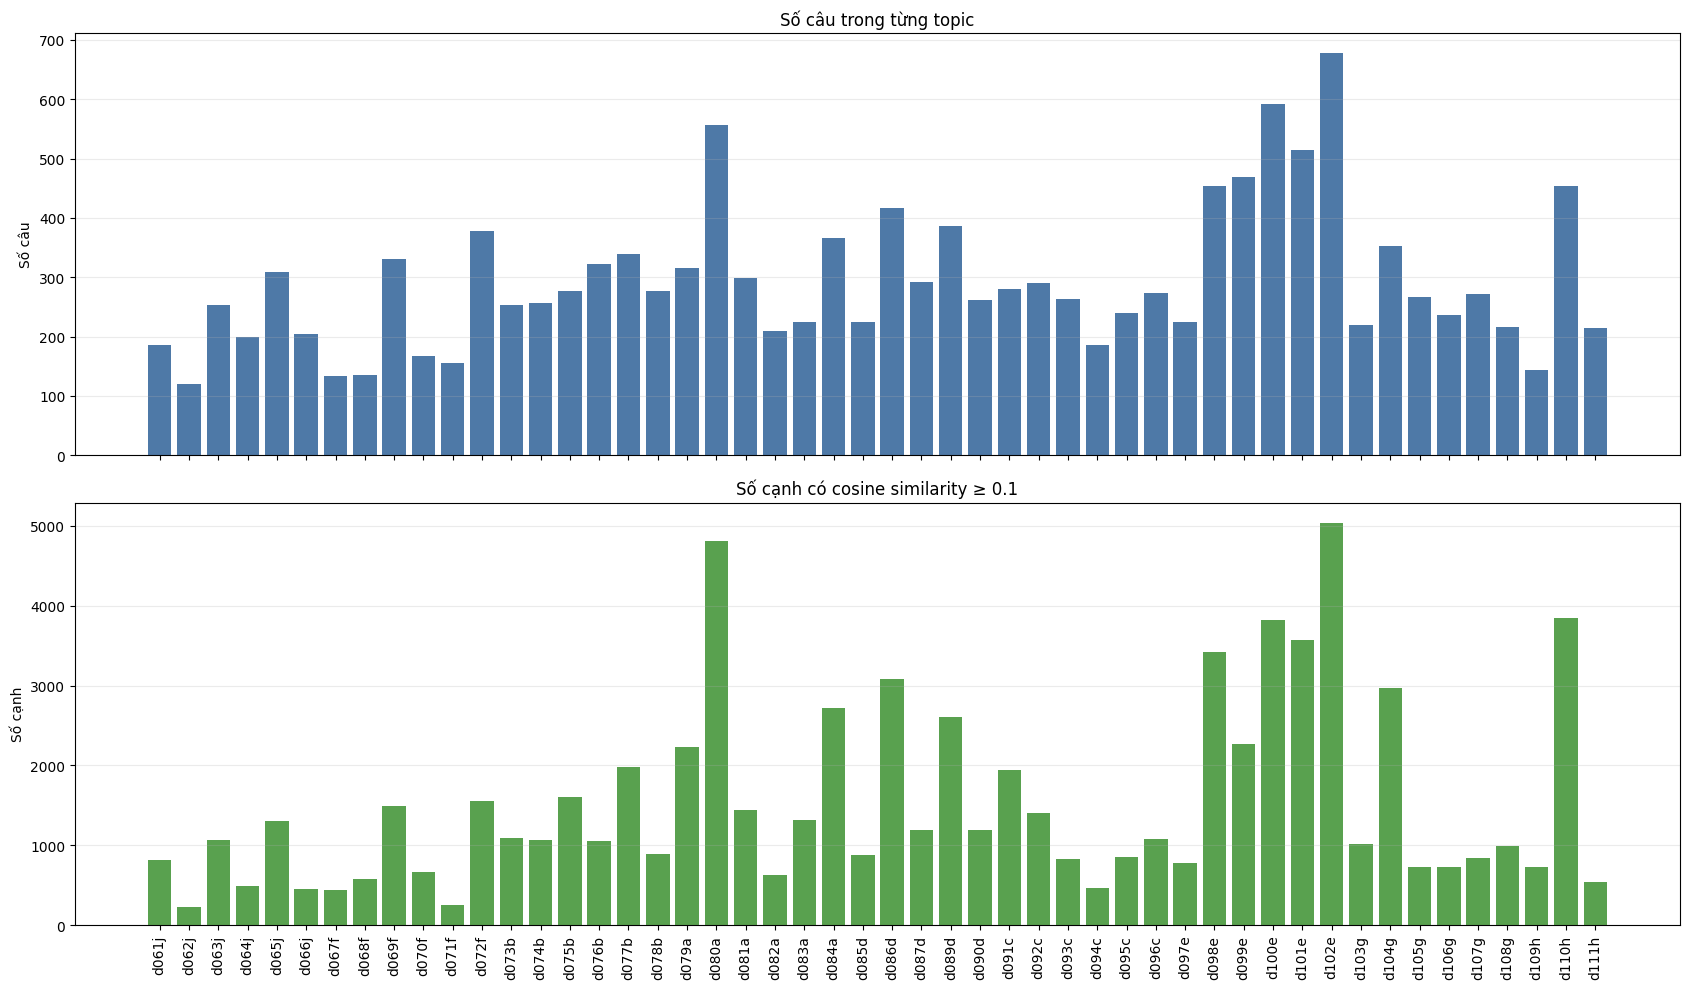

Đã lưu: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/all-documents-textrank-overview/topic-sentence-edge-overview.png


In [5]:
topic_names = [result['topic'] for result in topic_results]
sentence_counts = [result['sentences'] for result in topic_results]
edge_counts = [result['edges'] for result in topic_results]
x_positions = np.arange(len(topic_names))

fig, (sentence_ax, edge_ax) = plt.subplots(2, 1, figsize=(17, 10), sharex=True)
sentence_ax.bar(x_positions, sentence_counts, color='#4e79a7')
sentence_ax.set_title('Số câu trong từng topic')
sentence_ax.set_ylabel('Số câu')
sentence_ax.grid(axis='y', alpha=0.25)

edge_ax.bar(x_positions, edge_counts, color='#59a14f')
edge_ax.set_title(f'Số cạnh có cosine similarity ≥ {SIMILARITY_THRESHOLD}')
edge_ax.set_ylabel('Số cạnh')
edge_ax.set_xticks(x_positions)
edge_ax.set_xticklabels(topic_names, rotation=90)
edge_ax.grid(axis='y', alpha=0.25)

fig.tight_layout()
topic_stats_image = OUTPUT_DIR / 'topic-sentence-edge-overview.png'
fig.savefig(topic_stats_image, dpi=160, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {topic_stats_image}')

## 6. Biểu đồ tỷ lệ câu được chọn

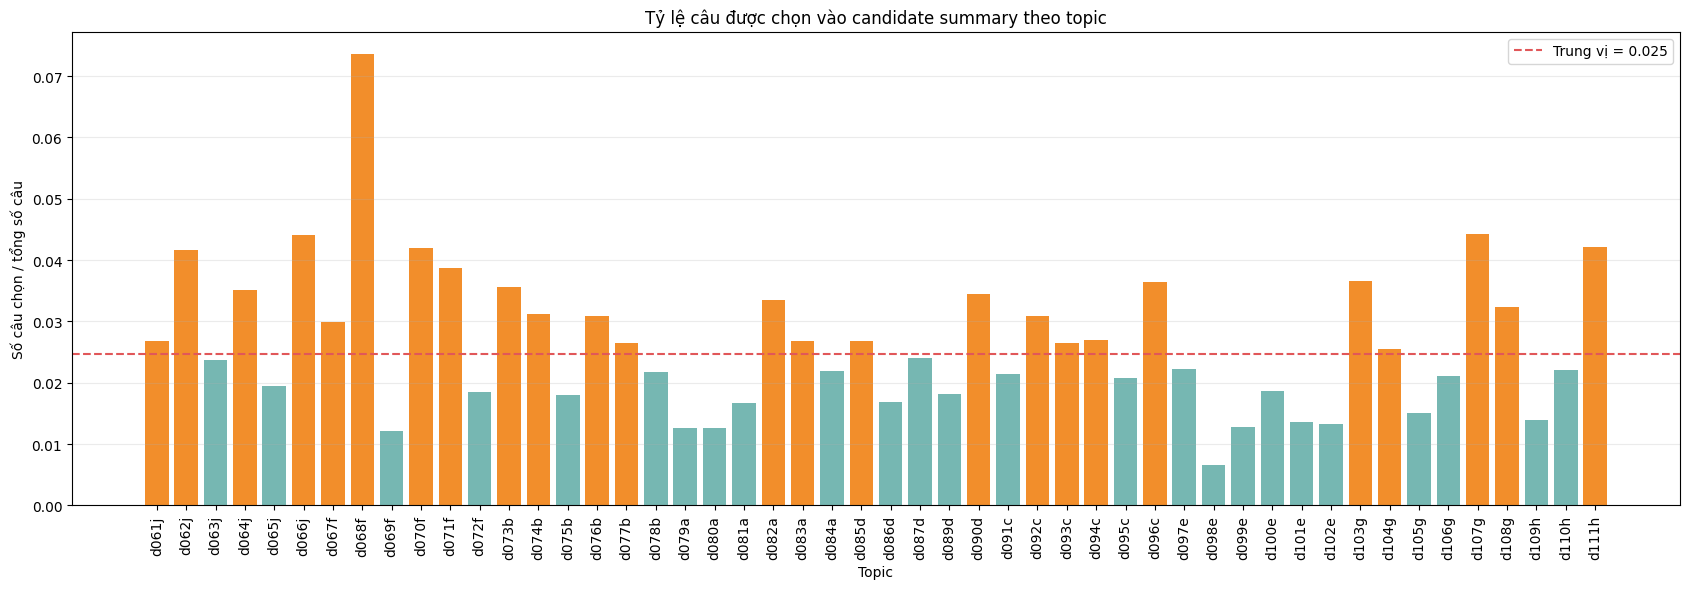

Đã lưu: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/all-documents-textrank-overview/topic-selection-ratio.png


In [6]:
selected_ratios = [
    result['selected'] / result['sentences'] if result['sentences'] else 0.0
    for result in topic_results
]
ratio_colors = ['#f28e2b' if ratio >= np.median(selected_ratios) else '#76b7b2' for ratio in selected_ratios]

fig, ax = plt.subplots(figsize=(17, 6))
ax.bar(x_positions, selected_ratios, color=ratio_colors)
ax.axhline(
    np.median(selected_ratios),
    color='#e15759',
    linestyle='--',
    linewidth=1.5,
    label=f'Trung vị = {np.median(selected_ratios):.3f}',
)
ax.set_title('Tỷ lệ câu được chọn vào candidate summary theo topic')
ax.set_xlabel('Topic')
ax.set_ylabel('Số câu chọn / tổng số câu')
ax.set_xticks(x_positions)
ax.set_xticklabels(topic_names, rotation=90)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()

selection_image = OUTPUT_DIR / 'topic-selection-ratio.png'
fig.savefig(selection_image, dpi=160, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {selection_image}')

## 7. Sơ đồ tương đồng giữa toàn bộ topic

Mỗi topic được biểu diễn bằng candidate summary của chính nó. Để sơ đồ không quá dày, mỗi topic chỉ nối với các topic tương đồng nhất; cạnh trùng được gộp lại.

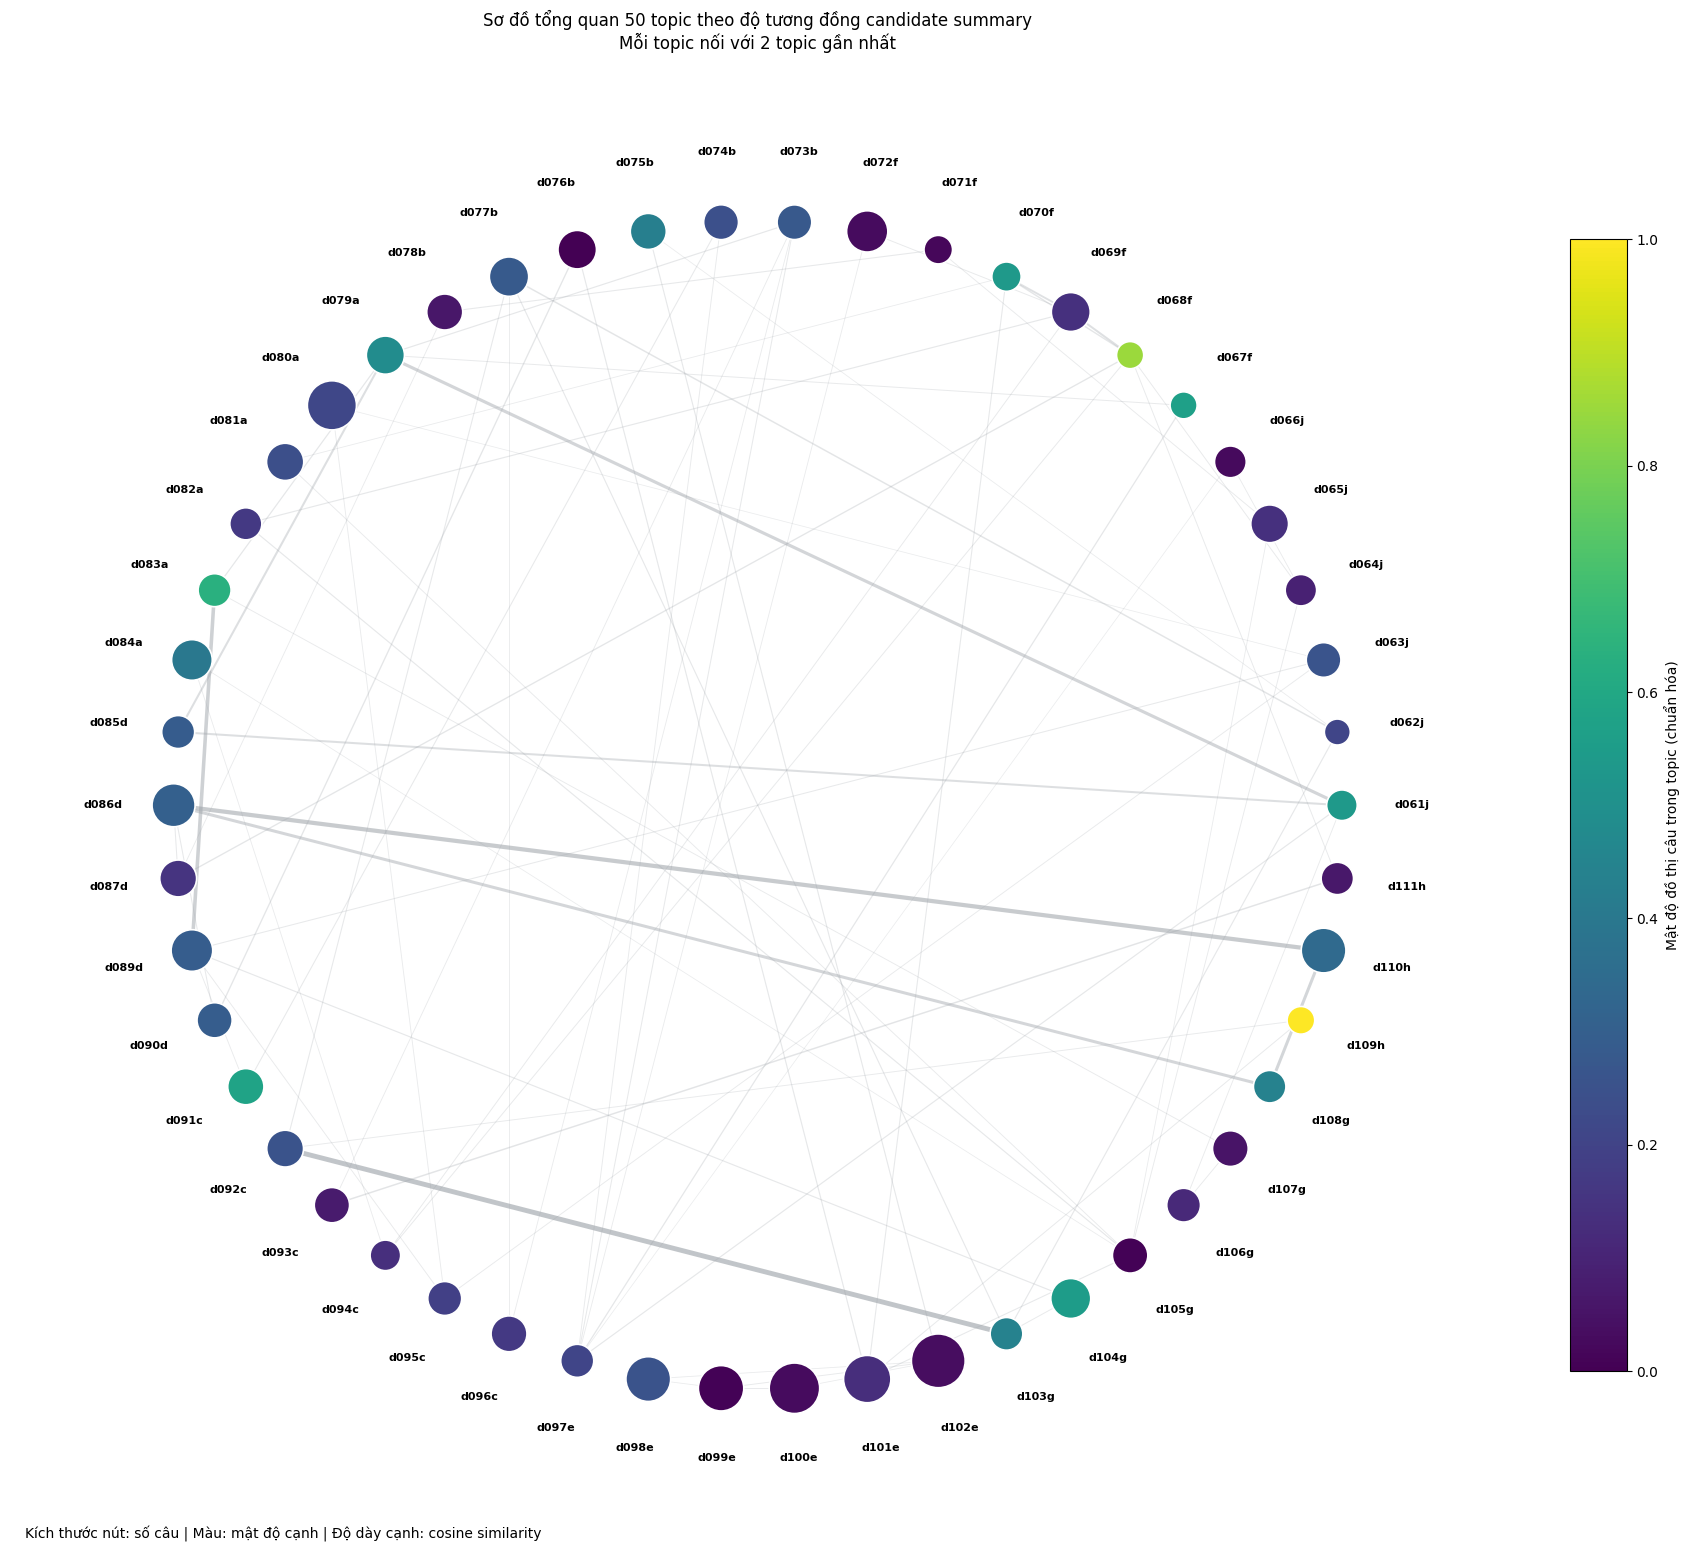

Đã lưu: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/all-documents-textrank-overview/all-topics-similarity-network.png


In [7]:
summary_sentences = [
    {'tokens': preprocess(result['summary_text'])}
    for result in topic_results
]
summary_vectors = calculate_tfidf_vectors(summary_sentences)

topic_similarities = np.zeros((len(topic_results), len(topic_results)))
for left_index in range(len(topic_results)):
    for right_index in range(left_index + 1, len(topic_results)):
        similarity = cosine_similarity(
            summary_vectors[left_index],
            summary_vectors[right_index],
        )
        topic_similarities[left_index, right_index] = similarity
        topic_similarities[right_index, left_index] = similarity

overview_edges = set()
for topic_index in range(len(topic_results)):
    neighbors = [index for index in range(len(topic_results)) if index != topic_index]
    neighbors.sort(key=lambda index: topic_similarities[topic_index, index], reverse=True)
    for neighbor_index in neighbors[:TOP_NEIGHBORS_PER_TOPIC]:
        left_index, right_index = sorted((topic_index, neighbor_index))
        overview_edges.add((left_index, right_index))

angles = np.linspace(0, 2 * np.pi, len(topic_results), endpoint=False)
positions = {
    index: (math.cos(angle), math.sin(angle))
    for index, angle in enumerate(angles)
}
sentence_min = min(sentence_counts)
sentence_max = max(sentence_counts)
density_values = [result['density'] for result in topic_results]
density_min = min(density_values)
density_max = max(density_values)

node_sizes = [
    350 + 1150 * (count - sentence_min) / max(1, sentence_max - sentence_min)
    for count in sentence_counts
]
node_colors = [
    (density - density_min) / max(1e-12, density_max - density_min)
    for density in density_values
]

fig, ax = plt.subplots(figsize=(17, 17))
for left_index, right_index in sorted(overview_edges):
    x_values = [positions[left_index][0], positions[right_index][0]]
    y_values = [positions[left_index][1], positions[right_index][1]]
    similarity = topic_similarities[left_index, right_index]
    ax.plot(
        x_values,
        y_values,
        color='#9aa0a6',
        linewidth=0.4 + 4.0 * similarity,
        alpha=0.18 + 0.55 * similarity,
        zorder=1,
    )

scatter = ax.scatter(
    [positions[index][0] for index in range(len(topic_results))],
    [positions[index][1] for index in range(len(topic_results))],
    s=node_sizes,
    c=node_colors,
    cmap='viridis',
    edgecolors='white',
    linewidths=1.2,
    zorder=2,
)

for index, topic_name in enumerate(topic_names):
    x_position, y_position = positions[index]
    label_radius = 1.12
    ax.text(
        label_radius * x_position,
        label_radius * y_position,
        topic_name,
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
    )

colorbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.04)
colorbar.set_label('Mật độ đồ thị câu trong topic (chuẩn hóa)')
ax.set_title(
    f'Sơ đồ tổng quan {len(topic_results)} topic theo độ tương đồng candidate summary\n'
    f'Mỗi topic nối với {TOP_NEIGHBORS_PER_TOPIC} topic gần nhất'
)
ax.text(
    0.01,
    0.01,
    'Kích thước nút: số câu | Màu: mật độ cạnh | Độ dày cạnh: cosine similarity',
    transform=ax.transAxes,
    fontsize=10,
    bbox={'facecolor': 'white', 'alpha': 0.9, 'edgecolor': 'none'},
)
ax.set_aspect('equal')
ax.set_xlim(-1.28, 1.28)
ax.set_ylim(-1.28, 1.28)
ax.axis('off')
fig.tight_layout()

network_image = OUTPUT_DIR / 'all-topics-similarity-network.png'
fig.savefig(network_image, dpi=160, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {network_image}')

## 8. Cách đọc kết quả

- Biểu đồ thứ nhất cho biết quy mô và số liên kết câu của từng topic.
- Biểu đồ thứ hai cho biết mức độ cô đọng của candidate summary.
- Trong sơ đồ tổng quan, nút lớn là topic có nhiều câu; cạnh dày là hai candidate summary giống nhau hơn.
- Sơ đồ chỉ là phép chiếu tổng quan theo cosine similarity, không phải nhãn chủ đề chuẩn hay kết quả đánh giá chất lượng summary.